# 03 — Stage 1 diagnostics

Reads `outputs/stage1/` and asks four questions in order, because a later one is
meaningless if an earlier one fails:

1. **Did the solve converge?** — not "did it finish". `bayesian_skymap` has a documented
   history of silently divergent solves accepted as valid samples, so stage 1 cross-checks
   its Krylov answer against an exact reference and refuses to write a product that fails.
2. **Does the model describe the ring?** — reduced χ² and the residuals.
3. **Did the data actually move the map?** — prior → posterior σ shrinkage and z-scores.
4. **Is the product fit to hand to stage 3?** — the degrade to `beam.nside_new`, and the
   spectral index between the two solved maps.

Run stage 1 first if `outputs/stage1/` is empty:

```
python run_pipeline.py --stage 1
```

In [1]:
%matplotlib inline
import os
os.environ["TQDM_DISABLE"] = "1"

import sys
import warnings
from pathlib import Path

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.stats import norm

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "figure.facecolor": "white"})

from moonrunes.config import load_config
from moonrunes.stage1_tris_maps import load_stage1, import_limtod_tris

config = load_config(REPO / "configs" / "run_config.yaml")
tris = import_limtod_tris(config)
BORESIGHT_DEC = tris.TRIS_SITE_LATITUDE_DEG
products = load_stage1(config)
manifest = products.manifest

FREQS = [int(f) for f in products.frequencies_mhz]
NSIDE = products.nside
NPIX_BAND = products.pixel_indices.size

print("maps     ", products.maps_path)
print("manifest ", products.manifest_path)
print("written  ", manifest["written_utc"])
print()
print(f"run '{manifest['run_name']}': {FREQS} MHz, nside {NSIDE}, "
      f"{NPIX_BAND} pixels in the band, "
      f"{products['data_k'].shape[1]} samples per ring")
print(f"mapmaker {manifest['config_used']['tris']['mapmaker']}, "
      f"solver {manifest['config_used']['tris']['solver']['method']}, "
      f"prior {manifest['config_used']['tris']['prior']['template']}")

maps      /Users/user/Documents/Codes/project3/moonrunes/outputs/stage1/tris_maps_tris_haslam_v0.npz
manifest  /Users/user/Documents/Codes/project3/moonrunes/outputs/stage1/stage1_manifest.json
written   2026-09-03T17:12:17+00:00

run 'tris_haslam_v0': [600, 820] MHz, nside 64, 25704 pixels in the band, 120 samples per ring
mapmaker prior_regularized, solver gmres, prior gsm2008


---
## 1. Did the solve converge?

Stage 1 solves the MAP system matrix-free — a `LinearOperator` around
$(A^\mathsf{T}N^{-1}A + P^{-1})$ plus a Jacobi-preconditioned Krylov solve, the same
pattern as `bayesian_skymap`'s amplitude step, and explicitly **not** the Woodbury fast
path Blocker 3 rules out.

`info == 0` alone is not evidence of anything, so every solve is compared against the
exact Woodbury identity at a single frequency (the inner matrix is only
`n_samples × n_samples`). The discrepancy is quoted **in posterior σ**, which is the unit
in which a solver error either matters or does not: the residual norm is a poor proxy
here because the prior width spans an order of magnitude across the band.

In [2]:
print(f"{'nu':>5}{'method':>9}{'info':>6}{'iters':>7}{'rel. resid':>12}"
      f"{'σ from exact':>14}{'tolerance':>11}{'time [s]':>10}   verdict")
for freq in FREQS:
    s = products.diagnostics(freq)["solver"]
    ok = (s["info"] == 0) and (s["krylov_vs_woodbury_sigma"] < s["cross_check_max_sigma"])
    print(f"{freq:5d}{s['method']:>9}{s['info']:6d}{s['iterations']:7d}"
          f"{s['relative_residual']:12.2e}{s['krylov_vs_woodbury_sigma']:14.2e}"
          f"{s['cross_check_max_sigma']:11.1e}{s['seconds']:10.2f}   "
          f"{'converged' if ok else 'FAILED'}")
print("\n" + manifest["blocker_3_note"])

   nu   method  info  iters  rel. resid  σ from exact  tolerance  time [s]   verdict
  600    gmres     0    114    7.91e-13      1.65e-07    1.0e-04      0.30   converged
  820    gmres     0     72    3.09e-14      1.78e-09    1.0e-04      0.15   converged

The map solve is the direct Krylov solve (LinearOperator + gmres), never the multi-frequency Woodbury acceleration. The Woodbury identity used for the posterior variance is exact at a single frequency and is cross-checked against the Krylov mean.


---
## 2. Does the model describe the ring?

Reduced χ² is the first number to look at. Far above 1 means the prior and the operator
together cannot describe the ring — usually a sky template that is wrong at a level the
statistical errors can see. Notebook 01 measured exactly that: GSM2008 is ~1.9 K cold at
600 MHz.

   nu  reduced χ²  residual rms [K]  median stat. err [K]   ratio
  600       33.62            0.0830                0.0040    20.7
  820       13.25            0.0747                0.0040    18.7

The residual is tens of times the statistical error and is coherent in RA.
That is a misspecified template, not a badly tuned solver.


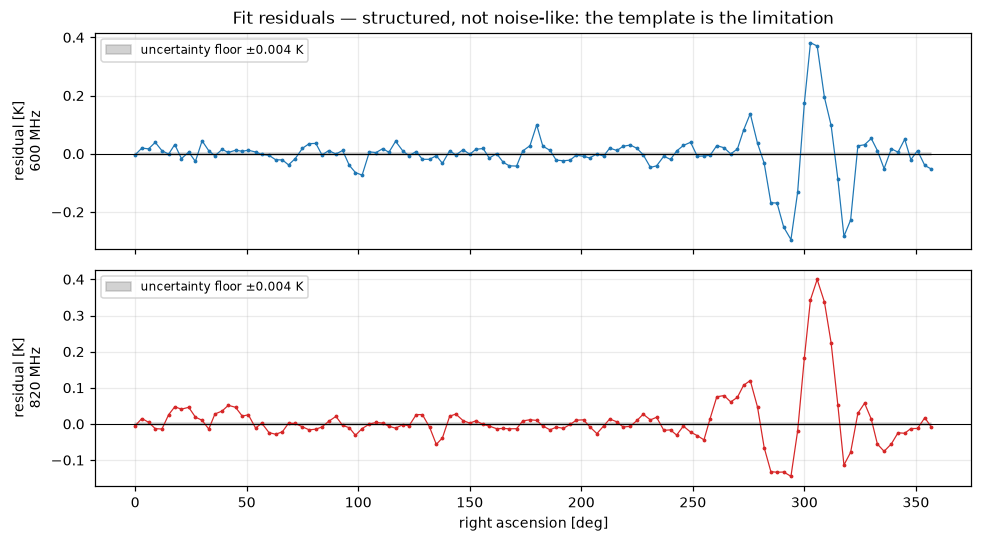

In [3]:
fig, axes = plt.subplots(len(FREQS), 1, figsize=(9, 2.5 * len(FREQS)), sharex=True)
axes = np.atleast_1d(axes)

print(f"{'nu':>5}{'reduced χ²':>12}{'residual rms [K]':>18}"
      f"{'median stat. err [K]':>22}{'ratio':>8}")
for ax, freq, colour in zip(axes, FREQS, ("tab:blue", "tab:red")):
    i = products.index(freq)
    d = products.diagnostics(freq)
    residual = products["residual_k"][i]
    ra = products["ra_deg"][i]
    # the ring's own statistical errors, floored the way stage 1 floored them
    stat = float(d["uncertainty_floor_k"])
    ax.plot(ra, residual, ".-", ms=3, lw=0.8, color=colour)
    ax.axhline(0, color="k", lw=0.7)
    ax.fill_between(ra, -stat, stat, color="grey", alpha=0.35,
                    label=f"uncertainty floor ±{stat:.3f} K")
    ax.set_ylabel(f"residual [K]\n{freq} MHz")
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
    print(f"{freq:5d}{d['reduced_chi_square']:12.2f}{d['residual_rms_k']:18.4f}"
          f"{stat:22.4f}{d['residual_rms_k']/stat:8.1f}")
axes[-1].set_xlabel("right ascension [deg]")
axes[0].set_title("Fit residuals — structured, not noise-like: the template is the "
                  "limitation")
fig.tight_layout()
print("\nThe residual is tens of times the statistical error and is coherent in RA.")
print("That is a misspecified template, not a badly tuned solver.")

---
## 3. The zero level, and the degeneracy behind it

The zero-level column is all ones, and the sky monopole's response is `beam_coverage`,
which is essentially constant for a normalised beam on a zenith drift scan. So a free zero
level and a free sky monopole are **not separately measurable from one ring** — the split
is set by the priors.

`monopole_degeneracy` (≈1) says how bad that is; `implied_monopole_prior_sigma_k` says
whether the sky prior is tight enough at the monopole for the fitted offset to mean
anything. And notebook 01's measured GSM2008 deficit says where the offset should land if
it is absorbing the template error rather than measuring the archive.

   nu     fitted zero level [K]   prior σ   pull  GSM2008 deficit  monopole degen.  implied monopole σ
  600          +1.7361 ± 0.0108      0.50   +3.5             1.92      1.000000000              0.0161
  820          +0.5148 ± 0.0069      0.50   +1.0             0.56      1.000000000              0.0086



Read this as: with a per-pixel prior this tight, the nuisance offset is the only
place the template's kelvin-scale error can go. It is a model-mismatch amplitude.


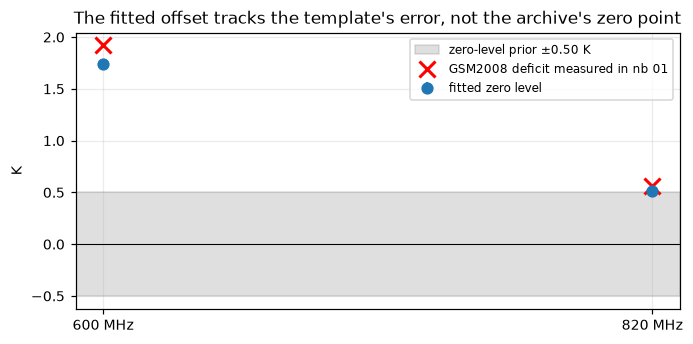

In [4]:
# Measured in 01_explore_tris_data.ipynb and in limTOD's own TRIS walkthrough:
# GSM2008 forward-modelled through this geometry runs cold against the absolute rings.
GSM2008_DEFICIT_K = {600: 1.92, 820: 0.56}

print(f"{'nu':>5}{'fitted zero level [K]':>26}{'prior σ':>10}{'pull':>7}"
      f"{'GSM2008 deficit':>17}{'monopole degen.':>17}{'implied monopole σ':>20}")
for freq in FREQS:
    d = products.diagnostics(freq)
    value = f"{d['zero_level_k']:+.4f} ± {d['zero_level_sigma_k']:.4f}"
    print(f"{freq:5d}{value:>26}{d['zero_level_prior_sigma_k']:10.2f}"
          f"{d['zero_level_pull_prior_sigma']:+7.1f}"
          f"{GSM2008_DEFICIT_K[freq]:17.2f}{d['monopole_degeneracy']:17.9f}"
          f"{d['implied_monopole_prior_sigma_k']:20.4f}")

fig, ax = plt.subplots(figsize=(6.4, 3.2))
x = np.arange(len(FREQS))
fitted = [products.diagnostics(f)["zero_level_k"] for f in FREQS]
errors = [products.diagnostics(f)["zero_level_sigma_k"] for f in FREQS]
prior_sigma = products.diagnostics(FREQS[0])["zero_level_prior_sigma_k"]
ax.axhspan(-prior_sigma, prior_sigma, color="grey", alpha=0.25,
           label=f"zero-level prior ±{prior_sigma:.2f} K")
ax.errorbar(x, fitted, yerr=errors, fmt="o", ms=7, lw=1.4, color="tab:blue",
            label="fitted zero level")
ax.plot(x, [GSM2008_DEFICIT_K[f] for f in FREQS], "rx", ms=10, mew=2,
        label="GSM2008 deficit measured in nb 01")
ax.axhline(0, color="k", lw=0.7)
ax.set_xticks(x); ax.set_xticklabels([f"{f} MHz" for f in FREQS])
ax.set_ylabel("K"); ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax.set_title("The fitted offset tracks the template's error, not the archive's zero point")
fig.tight_layout()

print("\nRead this as: with a per-pixel prior this tight, the nuisance offset is the only")
print("place the template's kelvin-scale error can go. It is a model-mismatch amplitude.")

---
## 4. Did the data actually move the map?

Two separate questions, and they have different answers:

* **Did the uncertainty shrink?** — the posterior σ against the prior σ. 120 samples
  cannot tighten thousands of pixels, so mostly no.
* **Did the mean move, and is that move consistent?** — the z-score. For a
  linear-Gaussian model the shift of the posterior mean away from the prior mean has
  covariance exactly $S - \Sigma$, so the right standardising width per pixel is
  $\sqrt{\sigma^2_\mathrm{prior} - \sigma^2_\mathrm{post}}$: the variance the data
  actually resolved. Dividing by $\sigma_\mathrm{prior}$ instead understates the tension.

In [5]:
def resolved_z(prior_mean, prior_sigma, post_mean, post_sigma, min_resolved_frac):
    resolved = np.sqrt(np.maximum(prior_sigma**2 - post_sigma**2, 0.0))
    usable = resolved > min_resolved_frac * prior_sigma
    z = np.full(prior_mean.shape, np.nan)
    z[usable] = (post_mean - prior_mean)[usable] / resolved[usable]
    return z, resolved, usable

print(f"{'nu':>5}{'median σ_prior':>16}{'median σ_post':>15}{'median ratio':>14}"
      f"{'pixels tightened >5%':>22}")
for freq in FREQS:
    i = products.index(freq)
    ratio = products["sky_sigma_k"][i] / products["prior_sigma_k"][i]
    print(f"{freq:5d}{np.median(products['prior_sigma_k'][i]):16.4f}"
          f"{np.median(products['sky_sigma_k'][i]):15.4f}{np.median(ratio):14.5f}"
          f"{int((ratio < 0.95).sum()):>13d} / {ratio.size}")

THRESHOLDS = (0.05, 0.01, 1e-3, 1e-4)
print("\nPixels whose RESOLVED width sqrt(σ²prior − σ²post) exceeds this fraction of")
print("σ_prior.  This is a weaker condition than the σ ratio above -- the difference is")
print("in quadrature, so resolving 5% of the prior width only shrinks σ by 0.1%.")
print(f"{'nu':>5}" + "".join(f"{f'>{t:g}':>10}" for t in THRESHOLDS)
      + f"{'of':>10}")
for freq in FREQS:
    i = products.index(freq)
    resolved = np.sqrt(np.maximum(products["prior_sigma_k"][i]**2
                                  - products["sky_sigma_k"][i]**2, 0.0))
    counts = [int((resolved > t * products["prior_sigma_k"][i]).sum())
              for t in THRESHOLDS]
    print(f"{freq:5d}" + "".join(f"{c:10d}" for c in counts) + f"{resolved.size:10d}")
print("\nThe honest headline: the posterior σ is within 0.01% of the prior σ almost")
print("everywhere, so the map is very largely the prior redisplayed. The ring does")
print("resolve a few percent of the prior width across ~10% of the band, and that")
print("small resolved variance is exactly the denominator the z-score below uses.")

   nu  median σ_prior  median σ_post  median ratio  pixels tightened >5%
  600          1.1553         1.1550       0.99998            2 / 25704
  820          0.7044         0.7042       0.99999            2 / 25704

Pixels whose RESOLVED width sqrt(σ²prior − σ²post) exceeds this fraction of
σ_prior.  This is a weaker condition than the σ ratio above -- the difference is
in quadrature, so resolving 5% of the prior width only shrinks σ by 0.1%.
   nu     >0.05     >0.01    >0.001   >0.0001        of
  600      2862     10925     18287     23858     25704
  820      1941     10639     18036     23500     25704

The honest headline: the posterior σ is within 0.01% of the prior σ almost
everywhere, so the map is very largely the prior redisplayed. The ring does
resolve a few percent of the prior width across ~10% of the band, and that
small resolved variance is exactly the denominator the z-score below uses.


600 MHz: z-scores over the 2862/25704 pixels that resolved >0.05 of their prior width
   (pixels below that threshold have a denominator consistent with zero, so
    their z carries no information and is excluded rather than plotted huge)
   mean +0.68   std 11.85   |z|>3 in 75% of pixels (N(0,1) would give 0.3%)


Text(0.5, 1.0, '|z| dips where the beam dwelt')

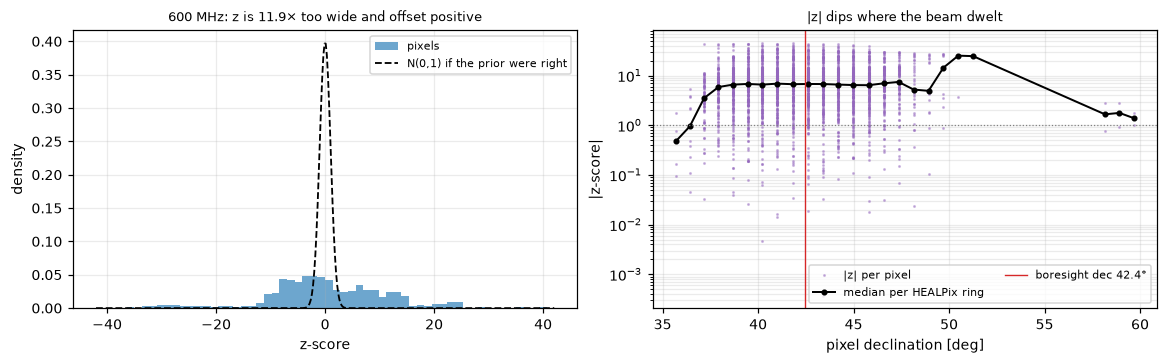

In [6]:
# Pick a threshold that actually leaves pixels to look at, and say which one was used.
FREQ_MAIN = FREQS[0]
i = products.index(FREQ_MAIN)
prior_mean = products["prior_mean_k"][i]
prior_sigma = products["prior_sigma_k"][i]
post_mean = products["sky_k"][i]
post_sigma = products["sky_sigma_k"][i]

MIN_USABLE_PIXELS = 200   # enough to see a distribution, not a fixed fraction
for THRESHOLD in (0.05, 0.01, 1e-3, 1e-4, 1e-6):
    z, resolved, usable = resolved_z(prior_mean, prior_sigma, post_mean, post_sigma,
                                     THRESHOLD)
    if usable.sum() >= MIN_USABLE_PIXELS:
        break
finite = z[np.isfinite(z)]
print(f"{FREQ_MAIN} MHz: z-scores over the {finite.size}/{z.size} pixels that resolved "
      f">{THRESHOLD:g} of their prior width")
print("   (pixels below that threshold have a denominator consistent with zero, so")
print("    their z carries no information and is excluded rather than plotted huge)")
print(f"   mean {finite.mean():+.2f}   std {finite.std():.2f}   "
      f"|z|>3 in {100*np.mean(np.abs(finite) > 3):.0f}% of pixels "
      f"(N(0,1) would give 0.3%)")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.2), constrained_layout=True)
ax = axes[0]
lim = float(np.percentile(np.abs(finite), 99.5))
ax.hist(finite, bins=60, range=(-lim, lim), density=True, alpha=0.65, color="tab:blue",
        label="pixels")
grid = np.linspace(-lim, lim, 400)
ax.plot(grid, norm.pdf(grid), "k--", lw=1.2, label="N(0,1) if the prior were right")
ax.set_xlabel("z-score"); ax.set_ylabel("density"); ax.legend(fontsize=7.5)
ax.grid(alpha=0.25)
ax.set_title(f"{FREQ_MAIN} MHz: z is {finite.std():.1f}× too wide"
             + (" and offset positive" if finite.mean() > 0 else ""), fontsize=8.5)

ax = axes[1]
dec_pix = 90 - np.rad2deg(hp.pix2ang(NSIDE, products.pixel_indices)[0])
ax.plot(dec_pix[usable], np.abs(z[usable]), ".", ms=2, color="tab:purple", alpha=0.4,
        label="|z| per pixel")
rings = np.unique(np.round(dec_pix[usable], 3))
median = np.array([np.median(np.abs(z[usable][np.round(dec_pix[usable], 3) == r]))
                   for r in rings])
ax.plot(rings, median, "o-", ms=3, lw=1.3, color="k", label="median per HEALPix ring")
ax.axhline(1.0, color="grey", lw=0.8, ls=":")
ax.axvline(BORESIGHT_DEC, color="tab:red", lw=0.9,
           label=f"boresight dec {BORESIGHT_DEC:.1f}°")
ax.set_yscale("log")
ax.set_xlabel("pixel declination [deg]"); ax.set_ylabel("|z-score|")
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.25, which="both")
ax.set_title("|z| dips where the beam dwelt", fontsize=8.5)

### The band, drawn

The solved region is a declination band, so a Mollweide projection would spend half its
area on sky that was never fitted. These panels project just the band, keeping HEALPix
pixel boundaries (`interpolation="nearest"`), with grey for pixels outside it. Prior and
posterior share a colour scale so the comparison is honest.

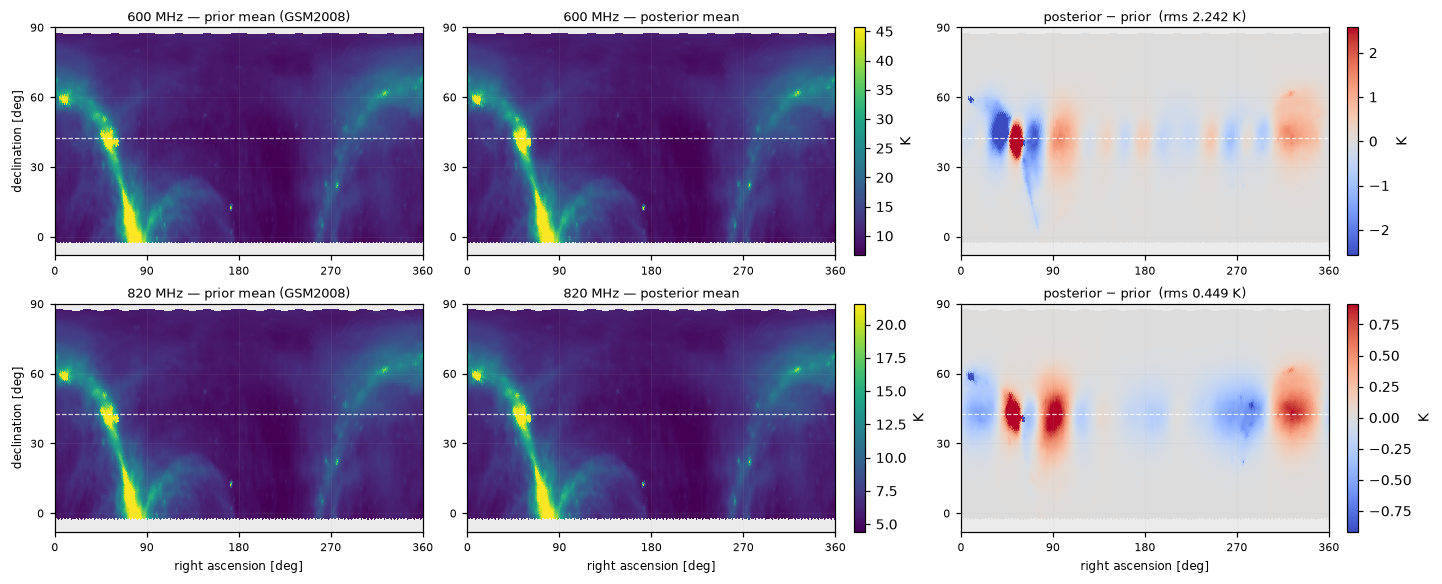

In [7]:
LATRA, LONRA = [-8, 90], [-180, 180]
EXTENT = [LONRA[0], LONRA[1], LATRA[0], LATRA[1]]

def band_image(values):
    full = np.full(hp.nside2npix(NSIDE), np.nan)
    full[products.pixel_indices] = values
    img = hp.cartview(full, lonra=LONRA, latra=LATRA, rot=[180, 0, 0], xsize=1200,
                      return_projected_map=True, hold=False)
    plt.close()
    return np.asarray(img)

def show_band(ax, values, cmap, title, **kw):
    im = ax.imshow(band_image(values), origin="lower", extent=EXTENT, aspect="auto",
                   cmap=cmap, interpolation="nearest", **kw)
    ax.set_title(title, fontsize=8.5, pad=4)
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_xticklabels(["0", "90", "180", "270", "360"])
    ax.set_yticks([0, 30, 60, 90]); ax.tick_params(labelsize=7.5)
    ax.set_facecolor("0.92")
    ax.axhline(BORESIGHT_DEC, color="w", lw=0.8, ls="--", alpha=0.8)
    ax.grid(alpha=0.15, lw=0.4)
    return im

fig, axes = plt.subplots(len(FREQS), 3, figsize=(13, 2.6 * len(FREQS)),
                         constrained_layout=True, squeeze=False)
for row, freq in enumerate(FREQS):
    i = products.index(freq)
    lo, hi = np.percentile(products["prior_mean_k"][i], [1, 99])
    im_m = show_band(axes[row, 0], products["prior_mean_k"][i], "viridis",
                     f"{freq} MHz — prior mean (GSM2008)", vmin=lo, vmax=hi)
    show_band(axes[row, 1], products["sky_k"][i], "viridis",
              f"{freq} MHz — posterior mean", vmin=lo, vmax=hi)
    change = products["sky_k"][i] - products["prior_mean_k"][i]
    clim = float(np.percentile(np.abs(change), 99))
    im_d = show_band(axes[row, 2], change, "coolwarm",
                     f"posterior − prior  (rms {change.std():.3f} K)",
                     vmin=-clim, vmax=clim)
    fig.colorbar(im_m, ax=list(axes[row, :2]), fraction=0.025, pad=0.01, label="K")
    fig.colorbar(im_d, ax=axes[row, 2], fraction=0.045, pad=0.02, label="K")
for ax in axes[-1]:
    ax.set_xlabel("right ascension [deg]", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("declination [deg]", fontsize=8)

---
## 5. Is this fit to hand to stage 3?

Two checks that matter downstream.

**The spectral index between the two solved maps.** Stage 4 infers β jointly, and
initialises six regions spanning −2.5 to −3.0. If stage 1's own two-frequency product
implies something wildly outside the Galactic synchrotron range, that is a red flag about
the maps, not a discovery. Note this is *not* independent of the prior: both maps are
largely GSM2008, so the template's own β is plotted alongside.

**The degrade to `beam.nside_new`.** Stage 3 writes `sky_lowres` with shape
`(Nfreq-1, npix_new)`. This is a preview of that array — stage 3 owns the real decision
about how to fill pixels the band never covered.

stage 1 maps       median β = -2.701   16-84% [-2.765, -2.657]    92.4% inside [-3.0, -2.5]
GSM2008 template   median β = -2.700   16-84% [-2.703, -2.698]   100.0% inside [-3.0, -2.5]


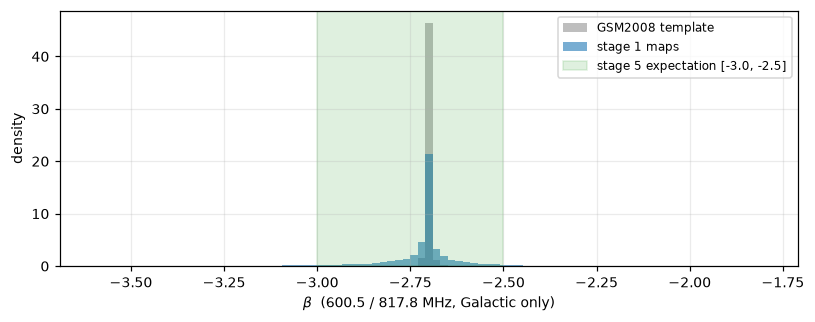

In [8]:
lo_i, hi_i = products.index(FREQS[0]), products.index(FREQS[-1])
nu_lo = products["effective_freq_mhz"][lo_i]
nu_hi = products["effective_freq_mhz"][hi_i]

def spectral_index(t_lo, t_hi):
    # Galactic-only: the TRIS convention includes the CMB monopole, so remove it
    # before taking a ratio or beta comes out meaningless.
    g_lo = t_lo - tris.cmb_monopole_rj_k(nu_lo)
    g_hi = t_hi - tris.cmb_monopole_rj_k(nu_hi)
    good = (g_lo > 0) & (g_hi > 0)
    beta = np.full(t_lo.shape, np.nan)
    beta[good] = np.log(g_lo[good] / g_hi[good]) / np.log(nu_lo / nu_hi)
    return beta

beta_post = spectral_index(products["sky_k"][lo_i], products["sky_k"][hi_i])
beta_prior = spectral_index(products["prior_mean_k"][lo_i],
                            products["prior_mean_k"][hi_i])
expected = config.require("validate.beta_range")

for label, beta in (("stage 1 maps", beta_post), ("GSM2008 template", beta_prior)):
    finite_beta = beta[np.isfinite(beta)]
    inside = np.mean((finite_beta >= expected[0]) & (finite_beta <= expected[1]))
    print(f"{label:18s} median β = {np.median(finite_beta):+.3f}   "
          f"16-84% [{np.percentile(finite_beta, 16):+.3f}, "
          f"{np.percentile(finite_beta, 84):+.3f}]   "
          f"{100*inside:5.1f}% inside {expected}")

fig, ax = plt.subplots(figsize=(7.5, 3.0))
bins = np.linspace(-3.6, -1.8, 90)
ax.hist(beta_prior[np.isfinite(beta_prior)], bins=bins, alpha=0.5, density=True,
        color="tab:grey", label="GSM2008 template")
ax.hist(beta_post[np.isfinite(beta_post)], bins=bins, alpha=0.6, density=True,
        color="tab:blue", label="stage 1 maps")
ax.axvspan(expected[0], expected[1], color="tab:green", alpha=0.15,
           label=f"stage 5 expectation {expected}")
ax.set_xlabel(rf"$\beta$  ({nu_lo:.1f} / {nu_hi:.1f} MHz, Galactic only)")
ax.set_ylabel("density"); ax.legend(fontsize=8); ax.grid(alpha=0.25)
fig.tight_layout()

stage 3 target grid: nside 8, 768 pixels, 432 touched by the band
sky_lowres preview shape would be (2, 432) (Nfreq, npix touched); bayesian_skymap wants (Nfreq-1, npix_new)
fully covered coarse pixels: 364, partially covered: 68

The partial ones are stage 3's decision, not stage 1's: they mix solved sky
with pixels the band never reached.


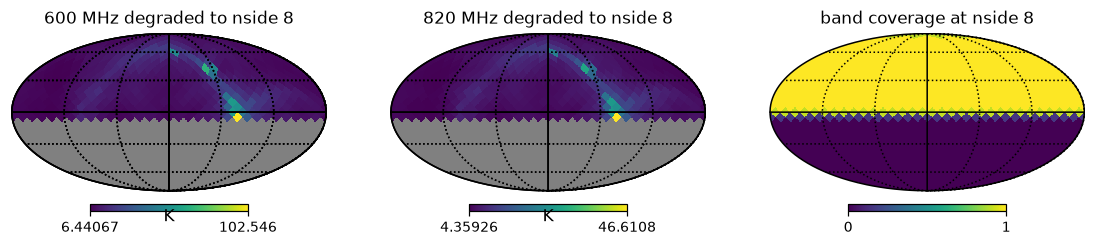

In [9]:
NSIDE_NEW = int(config.require("beam.nside_new"))

# Degrade by averaging only the band pixels each coarse pixel actually contains.
band = products["band_mask"]
coverage = hp.ud_grade(band.astype(float), NSIDE_NEW)
low_res = np.full((len(FREQS), hp.nside2npix(NSIDE_NEW)), np.nan)
for row, freq in enumerate(FREQS):
    filled = np.where(band, np.nan_to_num(products["sky_full_k"][row]), 0.0)
    summed = hp.ud_grade(filled, NSIDE_NEW)
    with np.errstate(invalid="ignore", divide="ignore"):
        low_res[row] = np.where(coverage > 0, summed / coverage, np.nan)

observed = coverage > 0
print(f"stage 3 target grid: nside {NSIDE_NEW}, {hp.nside2npix(NSIDE_NEW)} pixels, "
      f"{int(observed.sum())} touched by the band")
print(f"sky_lowres preview shape would be {low_res[:, observed].shape} "
      f"(Nfreq, npix touched); bayesian_skymap wants (Nfreq-1, npix_new)")
print(f"fully covered coarse pixels: {int((coverage > 0.999).sum())}, "
      f"partially covered: {int(((coverage > 0) & (coverage <= 0.999)).sum())}")
print("\nThe partial ones are stage 3's decision, not stage 1's: they mix solved sky")
print("with pixels the band never reached.")

fig, axes = plt.subplots(1, len(FREQS) + 1, figsize=(4.2 * (len(FREQS) + 1), 3.0))
for ax, freq, row in zip(axes, FREQS, range(len(FREQS))):
    plt.sca(ax)
    hp.mollview(np.where(np.isnan(low_res[row]), hp.UNSEEN, low_res[row]),
                title=f"{freq} MHz degraded to nside {NSIDE_NEW}", unit="K",
                hold=True, cbar=True, notext=True)
    hp.graticule(dpar=30, dmer=60)
plt.sca(axes[-1])
hp.mollview(coverage, title=f"band coverage at nside {NSIDE_NEW}", hold=True,
            cbar=True, notext=True, min=0, max=1)
hp.graticule(dpar=30, dmer=60)
fig.tight_layout()

---
## Verdict

Read the numbers above in this order:

1. **The solve is sound.** `info == 0` *and* agreement with the exact reference to far
   better than a posterior σ, at both frequencies. Nothing downstream is looking at a
   silently divergent answer.
2. **The model does not describe the ring** — reduced χ² of tens, with coherent
   structure in the residual. That is a statement about GSM2008, not about the map-maker.
3. **The fitted zero level reproduces the template's own deficit** (~1.9 K at 600 MHz,
   ~0.6 K at 820 MHz, measured independently in notebook 01). With a per-pixel prior this
   tight and a monopole degeneracy of ≈1, the nuisance offset is the only place a
   template error can go. Read it as a model-mismatch amplitude, **not** as a measurement
   of the archive's zero point.
4. **The map is largely the prior, redisplayed.** The posterior σ barely moves off the
   prior σ, and the z-scores are far wider than N(0,1) and skewed — the ring is
   systematically pulling the map away from GSM2008 in the directions it can see.

None of that is a stage 1 bug; it is what one absolutely-calibrated ring plus a template
that is kelvins off can support. The honest product of this stage is the *difference*
between TRIS and the template — which is precisely the absolutely-calibrated leg
`bayesian_skymap` needs for `data1`/`sky_lowres`.

**What would change it.** Blocker 2's real answer: a Haslam-independent prior from
Berkhuijsen (1972), built in `02_build_berkhijsen_prior.ipynb`, replacing GSM2008 as both
template and truth. Until then, `prior_equals_truth` is `True` in the manifest and
agreement with `truth_k` is circular by construction.